In [1]:
# Import libraries used throughout the recommendation system.
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import joblib  
import os

import warnings
warnings.filterwarnings('ignore')  


In [2]:
# Load the MovieLens datasets.
movies = pd.read_csv("dataset/movies.csv")
ratings = pd.read_csv("dataset/ratings.csv")
tags = pd.read_csv("dataset/tags.csv")
links = pd.read_csv("dataset/links.csv")

print("Movies Shape :",movies.shape)
print("Ratings Shape :",ratings.shape)
print("Tags Shape :",tags.shape)
print("Links Shape :",links.shape)

Movies Shape : (9742, 3)
Ratings Shape : (100836, 4)
Tags Shape : (3683, 4)
Links Shape : (9742, 3)


In [3]:
print(movies.head())
print(movies.info())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None


In [4]:
print(ratings.head())
print(ratings.info())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


In [5]:
print(tags.head())
print(tags.info())

   userId  movieId              tag   timestamp
0       2    60756            funny  1445714994
1       2    60756  Highly quotable  1445714996
2       2    60756     will ferrell  1445714992
3       2    89774     Boxing story  1445715207
4       2    89774              MMA  1445715200
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-null   int64 
 2   tag        3683 non-null   object
 3   timestamp  3683 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 115.2+ KB
None


In [6]:
print(links.head())
print(links.info())

   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9742 non-null   int64  
 1   imdbId   9742 non-null   int64  
 2   tmdbId   9734 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 228.5 KB
None


In [7]:
print("Movies")
print(movies.isnull().sum())

print("Ratings")
print(ratings.isnull().sum())

print("Tags")
print(tags.isnull().sum())

print("Links")
print(links.isnull().sum())

Movies
movieId    0
title      0
genres     0
dtype: int64
Ratings
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Tags
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64
Links
movieId    0
imdbId     0
tmdbId     8
dtype: int64


In [8]:
print("Movies :",movies.duplicated().sum())
print("Ratings :",ratings.duplicated().sum())
print("Tags :",tags.duplicated().sum())
print("Links :",links.duplicated().sum())

Movies : 0
Ratings : 0
Tags : 0
Links : 0


In [9]:
movies.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)  
tags.drop_duplicates(inplace=True)
links.drop_duplicates(inplace=True)

In [10]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [11]:
print("Total Moves :",movies['movieId'].nunique())
print("Total users :",ratings['userId'].nunique())
print("Total Ratings :",len(ratings))

Total Moves : 9742
Total users : 610
Total Ratings : 100836


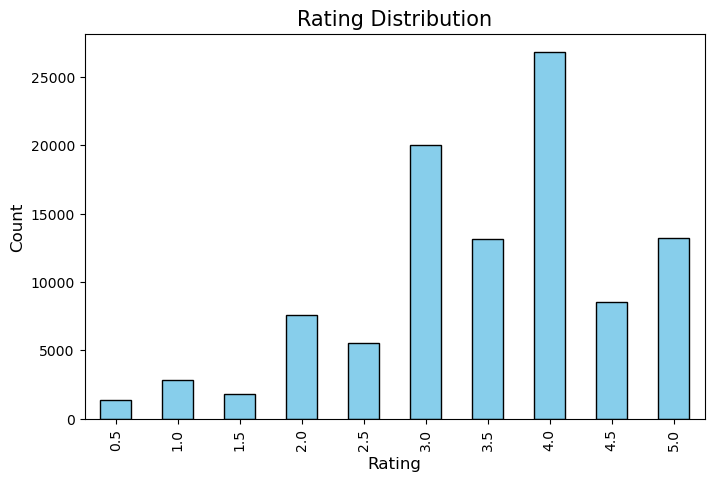

In [12]:
plt.figure(figsize=(8,5))

ratings["rating"].value_counts().sort_index().plot(
    kind='bar', color='skyblue', edgecolor='black'
)
plt.title("Rating Distribution", fontsize=15)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

In [13]:
movie_rating_count = ratings.groupby("movieId").size()

top_movies = movie_rating_count.sort_values(ascending=False).head(10)

top_movies = top_movies.reset_index()

top_movies = top_movies.merge( movies, on="movieId")

top_movies

,movieId,0,title,genres
0,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
1,318,317,"Shawshank Redemption, The (1994)",Crime|Drama
2,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
3,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
5,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
7,110,237,Braveheart (1995),Action|Drama|War
8,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi
9,527,220,Schindler's List (1993),Drama|War


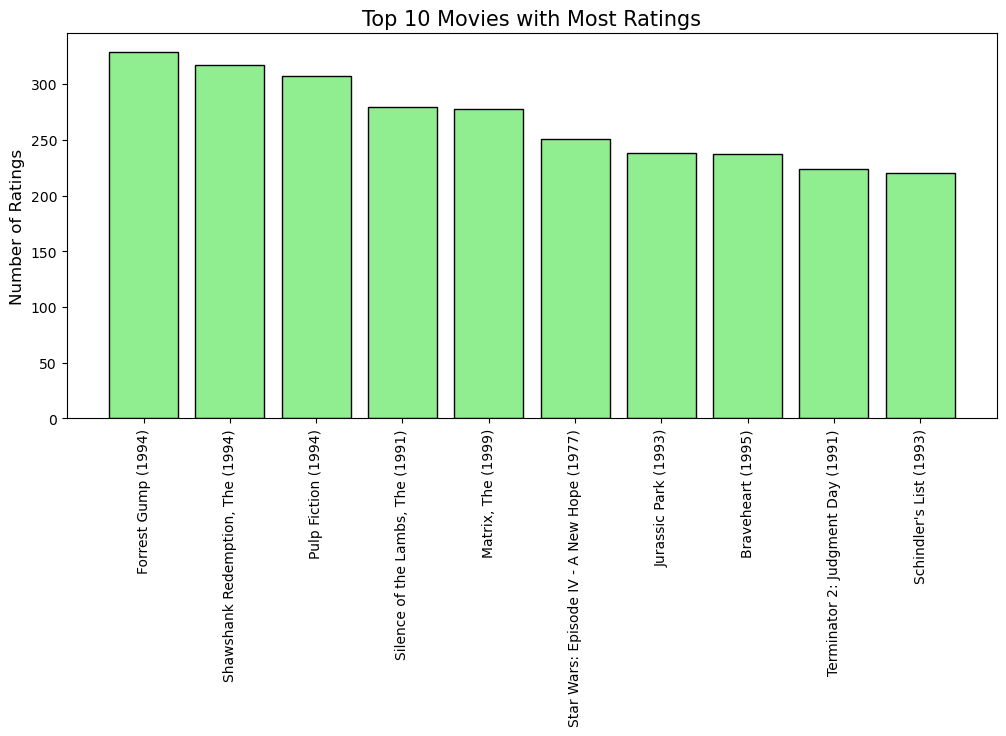

In [14]:
plt.figure(figsize=(12,5))

plt.bar(
    top_movies['title'], top_movies[0], color='lightgreen', edgecolor='black'
)
plt.xticks(rotation=90)
plt.title("Top 10 Movies with Most Ratings", fontsize=15)
plt.ylabel("Number of Ratings", fontsize=12)
plt.show()

In [15]:
genres = movies["genres"].str.split("|").explode()
genre_count = genres.value_counts()
genre_count.head(15)

genres
Drama          4361
Comedy         3756
Thriller       1894
Action         1828
Romance        1596
Adventure      1263
Crime          1199
Sci-Fi          980
Horror          978
Fantasy         779
Children        664
Animation       611
Mystery         573
Documentary     440
War             382
Name: count, dtype: int64

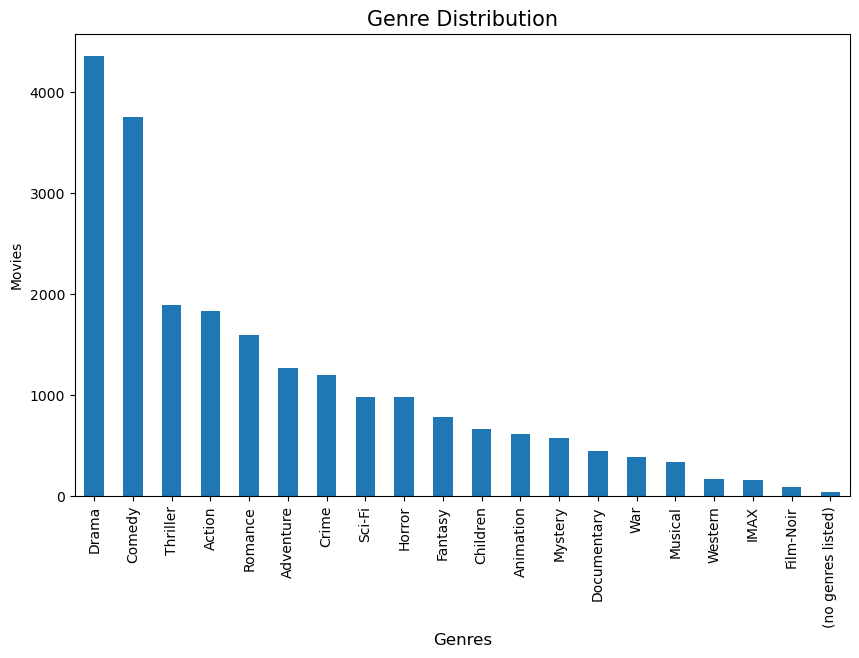

In [16]:
plt.figure(figsize=(10,6))
genre_count.plot(kind = "bar")
plt.title("Genre Distribution", fontsize=15)
plt.xlabel("Genres", fontsize=12)
plt.ylabel("Movies")
plt.show()

In [17]:
user_activity = ratings.groupby("userId").size()
user_activity.describe()

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

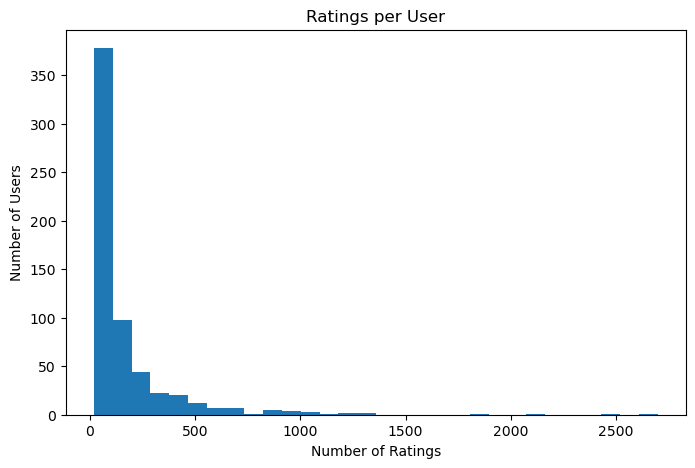

In [18]:
plt.figure(figsize = (8,5))
plt.hist(user_activity,bins = 30)
plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

In [19]:
# Create features for content-based recommendations.
tag_data = tags.groupby("movieId")["tag"].apply(
    lambda x: " ".join(x.astype(str))
).reset_index()

movies = movies.merge(tag_data, on="movieId", how="left")

movies["tags"] = movies["tag"].fillna("")

In [20]:
movies["content"]=(
    movies["genres"] + " " + movies["tags"]
)

In [21]:
movies[["movieId", "title", "genres", "tags","content"]].head()

,movieId,title,genres,tags,content
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,pixar pixar fun,Adventure|Animation|Children|Comedy|Fantasy pi...
1,2,Jumanji (1995),Adventure|Children|Fantasy,fantasy magic board game Robin Williams game,Adventure|Children|Fantasy fantasy magic board...
2,3,Grumpier Old Men (1995),Comedy|Romance,moldy old,Comedy|Romance moldy old
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,,Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake,Comedy pregnancy remake


In [22]:
tfidf = TfidfVectorizer(stop_words="english",max_features=5000)

tfidf_matrix = tfidf.fit_transform(movies["content"])
print(tfidf_matrix.shape)

(9742, 1677)


In [23]:
cosine_sim = cosine_similarity(tfidf_matrix)

print(cosine_sim.shape)

(9742, 9742)


In [24]:
movie_indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

In [25]:
def content_recommend(movie_title, n=10):

    # Check movie exists
    if movie_title not in movie_indices:
        print("Movie not found!")
        return

    idx = movie_indices[movie_title]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:n+1]

    movie_indexes = [i[0] for i in similarity_scores]

    recommendations = movies.iloc[movie_indexes][
        ['title', 'genres']
    ].copy()

    recommendations['Similarity Score'] = [
        round(i[1],3)
        for i in similarity_scores
    ]

    return recommendations.reset_index(drop=True)

In [26]:
content_recommend("Top Story (1995)")

Movie not found!


In [27]:
content_recommend("Jumanji (1995)")

,title,genres,Similarity Score
0,Tomb Raider (2018),Action|Adventure|Fantasy,0.356
1,Night at the Museum (2006),Action|Comedy|Fantasy|IMAX,0.354
2,"Indian in the Cupboard, The (1995)",Adventure|Children|Fantasy,0.303
3,"NeverEnding Story III, The (1994)",Adventure|Children|Fantasy,0.303
4,Escape to Witch Mountain (1975),Adventure|Children|Fantasy,0.303
5,Darby O'Gill and the Little People (1959),Adventure|Children|Fantasy,0.303
6,Return to Oz (1985),Adventure|Children|Fantasy,0.303
7,"NeverEnding Story, The (1984)",Adventure|Children|Fantasy,0.303
8,"NeverEnding Story II: The Next Chapter, The (1...",Adventure|Children|Fantasy,0.303
9,Santa Claus: The Movie (1985),Adventure|Children|Fantasy,0.303


In [28]:
content_recommend("The Matrix (1999)")

Movie not found!


In [29]:
if 'movies' not in globals():
    movies = pd.read_csv("dataset/movies.csv")

random_movie = movies.sample(1).iloc[0]['title']
print("Random Movie:", random_movie)

content_recommend(random_movie)
print("Random Movie:", random_movie)

content_recommend(random_movie)

Random Movie: Irrational Man (2015)
Random Movie: Irrational Man (2015)


,title,genres,Similarity Score
0,"Hate (Haine, La) (1995)",Crime|Drama,1.0
1,"Young Poisoner's Handbook, The (1995)",Crime|Drama,1.0
2,New Jersey Drive (1995),Crime|Drama,1.0
3,Jason's Lyric (1994),Crime|Drama,1.0
4,Above the Rim (1994),Crime|Drama,1.0
5,American Buffalo (1996),Crime|Drama,1.0
6,"Funeral, The (1996)",Crime|Drama,1.0
7,Once Upon a Time in America (1984),Crime|Drama,1.0
8,"Newton Boys, The (1998)",Crime|Drama,1.0
9,Fireworks (Hana-bi) (1997),Crime|Drama,1.0


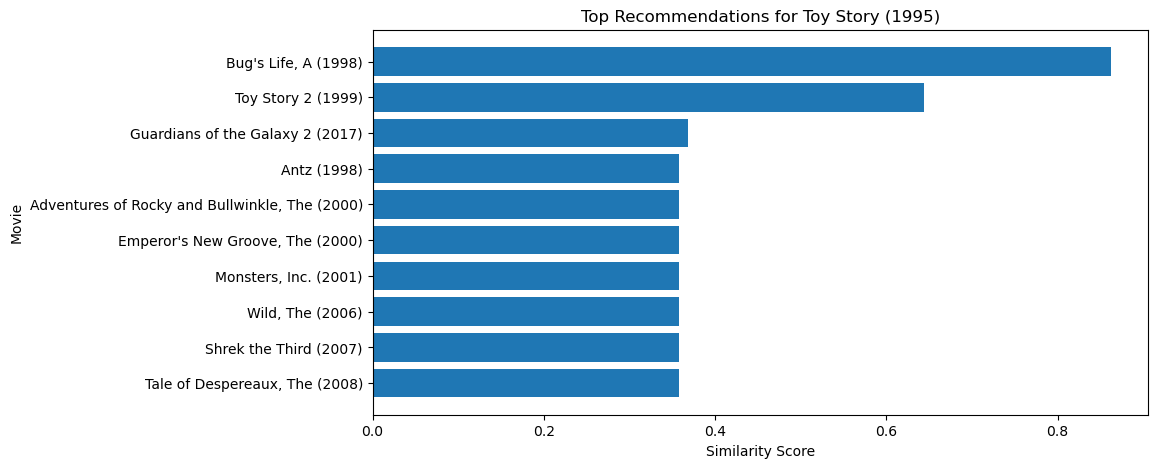

In [30]:
movie_name = "Toy Story (1995)"

recommendations = content_recommend(movie_name)

plt.figure(figsize=(10,5))

plt.barh(
    recommendations['title'],
    recommendations['Similarity Score']
)

plt.xlabel("Similarity Score")
plt.ylabel("Movie")

plt.title(f"Top Recommendations for {movie_name}")

plt.gca().invert_yaxis()

plt.show()

In [31]:
content_recommend("Toy Story (1995)",20)

,title,genres,Similarity Score
0,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.862
1,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.644
2,Guardians of the Galaxy 2 (2017),Action|Adventure|Sci-Fi,0.368
3,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.358
4,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.358
5,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.358
6,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.358
7,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,0.358
8,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,0.358
9,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,0.358


In [32]:
joblib.dump(cosine_sim,"cosine_similarity.pkl")

joblib.dump(tfidf,"tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [33]:
print(os.listdir())

['.ipynb_checkpoints', 'anaconda_projects', 'cosine_similarity.pkl', 'dataset', 'movie_recomendation.ipynb', 'tfidf_vectorizer.pkl']


In [34]:
print("Number of Movies :", len(movies))

print("TF-IDF Matrix Shape :", tfidf_matrix.shape)

print("Cosine Similarity Shape :", cosine_sim.shape)

Number of Movies : 9742
TF-IDF Matrix Shape : (9742, 1677)
Cosine Similarity Shape : (9742, 9742)


In [35]:
content_recommend("Toy Story (1995)")

,title,genres,Similarity Score
0,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.862
1,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.644
2,Guardians of the Galaxy 2 (2017),Action|Adventure|Sci-Fi,0.368
3,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.358
4,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.358
5,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.358
6,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.358
7,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,0.358
8,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,0.358
9,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,0.358


In [36]:
# Train and evaluate collaborative-filtering models.
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise import KNNBasic

from surprise.model_selection import train_test_split
from surprise.accuracy import rmse
from surprise.accuracy import mae

In [37]:
reader = Reader(rating_scale=(0.5,5.0))

data = Dataset.load_from_df(
    ratings[['userId','movieId','rating']],
    reader
)

In [38]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [39]:
svd_model = SVD(
    n_factors=100,
    random_state=42
)

svd_model.fit(trainset)

In [40]:
predictions = svd_model.test(testset)

In [41]:
print("SVD Results")

rmse(predictions)

mae(predictions)

SVD Results
RMSE: 0.8807
MAE:  0.6766


np.float64(0.6765729095860605)

In [42]:
user_id = 1
movie_id = 1

prediction = svd_model.predict(
    user_id,
    movie_id
)

print(prediction)

user: 1          item: 1          r_ui = None   est = 4.57   {'was_impossible': False}


In [43]:
for movie in [1,50,100,200,500]:
    
    pred = svd_model.predict(1,movie)
    
    print(
        movie,
        round(pred.est,2)
    )

1 4.57
50 5.0
100 3.76
200 4.2
500 4.11


In [44]:
sim_options = {
    "name":"cosine",
    "user_based":False
}

knn_model = KNNBasic(
    sim_options=sim_options
)

knn_model.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [45]:
knn_predictions = knn_model.test(testset)

print("KNN Results")

rmse(knn_predictions)

mae(knn_predictions)

KNN Results
RMSE: 0.9800
MAE:  0.7615


np.float64(0.7614697475628528)

In [46]:
comparison = pd.DataFrame({
    "Model":[
        "SVD",
        "KNNBasic"
    ],
    "RMSE":[
        rmse(predictions,verbose=False),
        rmse(knn_predictions,verbose=False)
    ],
    "MAE":[
        mae(predictions,verbose=False),
        mae(knn_predictions,verbose=False)
    ]
})

comparison

,Model,RMSE,MAE
0,SVD,0.880746,0.676573
1,KNNBasic,0.979957,0.761470


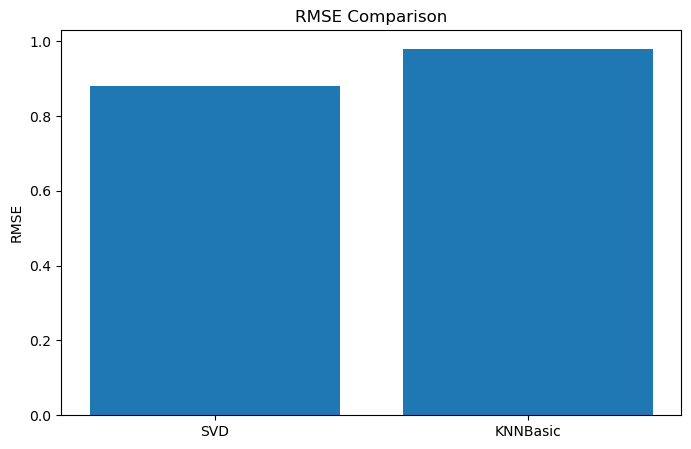

In [47]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("RMSE Comparison")

plt.ylabel("RMSE")

plt.show()

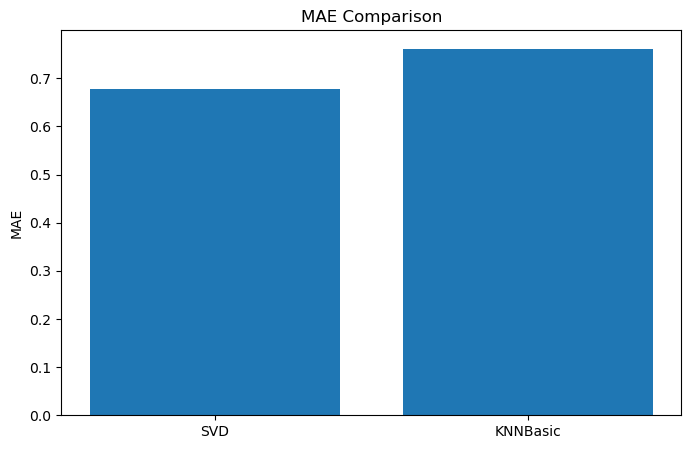

In [48]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.title("MAE Comparison")

plt.ylabel("MAE")

plt.show()

In [49]:
def recommend_for_user(user_id, n=10):

    movie_ids = movies['movieId'].unique()

    watched = ratings[
        ratings.userId == user_id
    ]['movieId']

    unseen = [
        movie
        for movie in movie_ids
        if movie not in watched.values
    ]

    predictions = []

    for movie in unseen:

        pred = svd_model.predict(
            user_id,
            movie
        )

        predictions.append(
            (
                movie,
                pred.est
            )
        )

    predictions.sort(
        key=lambda x:x[1],
        reverse=True
    )

    top = predictions[:n]

    result = pd.DataFrame(
        top,
        columns=[
            "movieId",
            "Predicted Rating"
        ]
    )

    result = result.merge(
        movies,
        on="movieId"
    )

    return result[
        [
            "title",
            "genres",
            "Predicted Rating"
        ]
    ]

In [50]:
recommend_for_user(1)

,title,genres,Predicted Rating
0,Blade Runner (1982),Action|Sci-Fi|Thriller,5.0
1,Ghost in the Shell (Kôkaku kidôtai) (1995),Animation|Sci-Fi,5.0
2,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0
3,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller,5.0
4,Casablanca (1942),Drama|Romance,5.0
5,"Streetcar Named Desire, A (1951)",Drama,5.0
6,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,5.0
7,One Flew Over the Cuckoo's Nest (1975),Drama,5.0
8,Lawrence of Arabia (1962),Adventure|Drama|War,5.0
9,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi,5.0


In [51]:
recommend_for_user(25)

,title,genres,Predicted Rating
0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,5.0
1,"Shawshank Redemption, The (1994)",Crime|Drama,5.0
2,Forrest Gump (1994),Comedy|Drama|Romance|War,5.0
3,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0
4,Rear Window (1954),Mystery|Thriller,5.0
5,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller,5.0
6,Some Like It Hot (1959),Comedy|Crime,5.0
7,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,5.0
8,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,5.0
9,"Good, the Bad and the Ugly, The (Buono, il bru...",Action|Adventure|Western,5.0


In [53]:

joblib.dump(
    svd_model,
    "svd_model.pkl"
)

['svd_model.pkl']

In [54]:
joblib.dump(
    knn_model,
    "knn_model.pkl"
)

['knn_model.pkl']

In [55]:
os.listdir()

['.ipynb_checkpoints',
 'anaconda_projects',
 'cosine_similarity.pkl',
 'dataset',
 'knn_model.pkl',
 'movie_recomendation.ipynb',
 'svd_model.pkl',
 'tfidf_vectorizer.pkl']

In [56]:
comparison.sort_values(
    "RMSE"
)


,Model,RMSE,MAE
0,SVD,0.880746,0.676573
1,KNNBasic,0.979957,0.761470


In [57]:
# Calculate ranking metrics for the SVD model.
from collections import defaultdict

In [58]:
predictions = svd_model.test(testset)


In [59]:
def get_top_k(predictions, k=10):

    top_k = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        top_k[uid].append((iid, est, true_r))

    for uid, user_ratings in top_k.items():
        user_ratings.sort(
            key=lambda x: x[1],
            reverse=True
        )

        top_k[uid] = user_ratings[:k]

    return top_k

In [60]:
def precision_recall_at_k(
    predictions,
    k=10,
    threshold=3.5
):

    top_k = get_top_k(predictions, k)

    precisions = {}
    recalls = {}

    for uid, user_ratings in top_k.items():

        relevant = sum(
            true_r >= threshold
            for (_, _, true_r) in user_ratings
        )

        recommended = sum(
            est >= threshold
            for (_, est, _) in user_ratings
        )

        relevant_recommended = sum(
            (true_r >= threshold) and (est >= threshold)
            for (_, est, true_r) in user_ratings
        )

        if recommended != 0:
            precisions[uid] = (
                relevant_recommended / recommended
            )
        else:
            precisions[uid] = 0

        if relevant != 0:
            recalls[uid] = (
                relevant_recommended / relevant
            )
        else:
            recalls[uid] = 0

    precision = sum(
        precisions.values()
    ) / len(precisions)

    recall = sum(
        recalls.values()
    ) / len(recalls)

    return precision, recall

In [61]:
precision, recall = precision_recall_at_k(
    predictions,
    k=10,
    threshold=3.5
)

print("Precision@10 :", round(precision,4))
print("Recall@10 :", round(recall,4))

Precision@10 : 0.7446
Recall@10 : 0.807


In [62]:
k_values = [5,10,15,20]

precision_scores = []

recall_scores = []

for k in k_values:

    p, r = precision_recall_at_k(
        predictions,
        k=k,
        threshold=3.5
    )

    precision_scores.append(p)

    recall_scores.append(r)

In [63]:
evaluation = pd.DataFrame({

    "K":k_values,

    "Precision":precision_scores,

    "Recall":recall_scores

})

evaluation

,K,Precision,Recall
0,5,0.755000,0.857158
1,10,0.744629,0.807040
2,15,0.736126,0.780701
3,20,0.734516,0.762352


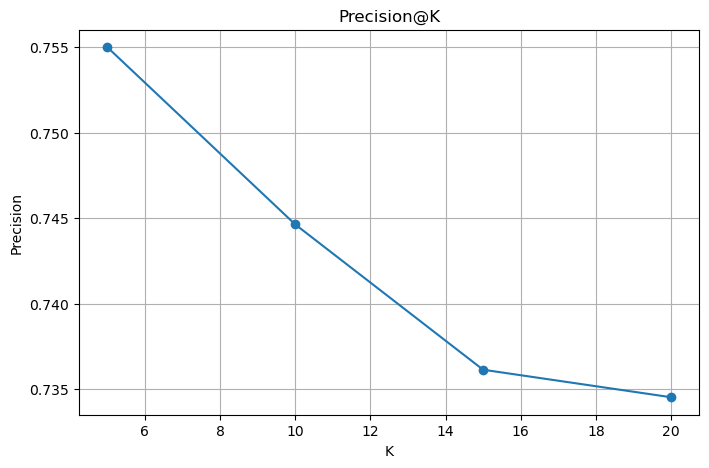

In [64]:
plt.figure(figsize=(8,5))

plt.plot(
    evaluation["K"],
    evaluation["Precision"],
    marker="o"
)

plt.title("Precision@K")

plt.xlabel("K")

plt.ylabel("Precision")

plt.grid(True)

plt.show()

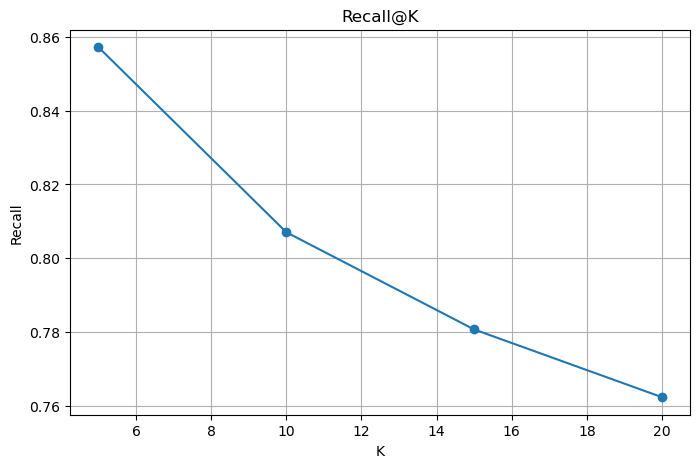

In [65]:
plt.figure(figsize=(8,5))

plt.plot(
    evaluation["K"],
    evaluation["Recall"],
    marker="o"
)

plt.title("Recall@K")

plt.xlabel("K")

plt.ylabel("Recall")

plt.grid(True)

plt.show()

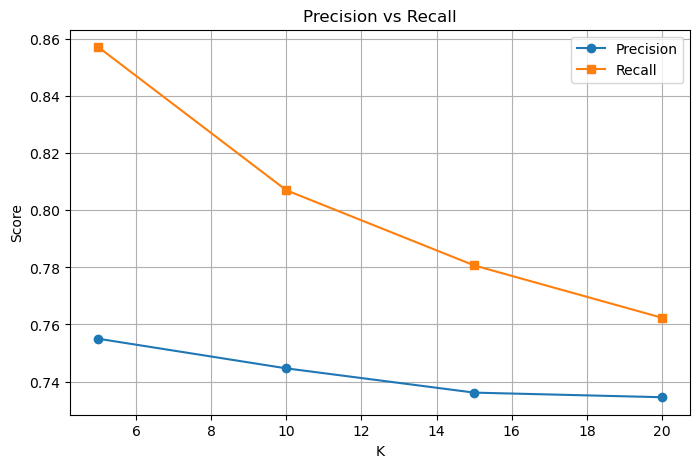

In [66]:
plt.figure(figsize=(8,5))

plt.plot(
    evaluation["K"],
    evaluation["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    evaluation["K"],
    evaluation["Recall"],
    marker="s",
    label="Recall"
)

plt.xlabel("K")

plt.ylabel("Score")

plt.title("Precision vs Recall")

plt.legend()

plt.grid(True)

plt.show()

In [68]:
results = pd.DataFrame({

    "Metric":[
        "RMSE",
        "MAE",
        "Precision@10",
        "Recall@10"
    ],

    "Value":[
        rmse(predictions,verbose=False),
        mae(predictions,verbose=False),
        precision,
        recall
    ]

})

results

,Metric,Value
0,RMSE,0.880746
1,MAE,0.676573
2,Precision@10,0.744629
3,Recall@10,0.807040


In [69]:
results.to_csv(
    "evaluation_results.csv",
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [70]:
print("=" * 50)
print("Movie Recommendation System Results")
print("=" * 50)

print(f"Number of Movies : {movies.shape[0]}")
print(f"Number of Users : {ratings['userId'].nunique()}")
print(f"Number of Ratings : {ratings.shape[0]}")

print("-" * 50)

print(f"RMSE : {rmse(predictions, verbose=False):.4f}")
print(f"MAE : {mae(predictions, verbose=False):.4f}")
print(f"Precision@10 : {precision:.4f}")
print(f"Recall@10 : {recall:.4f}")

Movie Recommendation System Results
Number of Movies : 9742
Number of Users : 610
Number of Ratings : 100836
--------------------------------------------------
RMSE : 0.8807
MAE : 0.6766
Precision@10 : 0.7446
Recall@10 : 0.8070
